# 02 - Variational AutoEncoder (VAE)

## 1. Setup & Imports

In [12]:
import os, sys, json, random, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as T
import torchvision.utils as vutils

from sklearn.metrics import accuracy_score, f1_score
from skimage.metrics import structural_similarity as ssim_metric
import kagglehub

# Install torchmetrics if needed
try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    from torchmetrics.image.inception import InceptionScore
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torchmetrics[image]', '-q'])
    from torchmetrics.image.fid import FrechetInceptionDistance
    from torchmetrics.image.inception import InceptionScore

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():            device = torch.device('cuda')
elif torch.backends.mps.is_available(): device = torch.device('mps')
else:                                    device = torch.device('cpu')
print('Device:', device)

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
for c in [os.path.join(NOTEBOOK_DIR,'../src'), os.path.join(NOTEBOOK_DIR,'src'),
          '/Applications/Universidade/4ano_2semestre/ACA/projeto2/aml-butterfly-generative-augmentation/src']:
    c = os.path.abspath(c)
    if os.path.isdir(c) and c not in sys.path:
        sys.path.append(c); break

from dataset import ButterflyDataset
from transforms import get_transforms
from models import BaselineCNN
from autoencoder import VAE, vae_loss
from utils import get_splits, get_class_mapping, GLOBAL_SEED
print('OK')

Device: mps
OK


## 2. Dados

In [13]:
path = kagglehub.competition_download('aca-tp-2')
train_dir = os.path.join(path, 'train')

df = pd.read_csv(os.path.join(path, 'train.csv'))[['filename', 'label']]
train_df, val_df = get_splits(df, seed=GLOBAL_SEED)
class_to_idx, idx_to_class, classes = get_class_mapping(df)
NUM_CLASSES = len(classes)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Classes: {NUM_CLASSES}')

Train: 4159 | Val: 1040 | Classes: 75


## 3. Funções Auxiliares

In [14]:
IMAGE_SIZE = 64
BATCH_SIZE = 64

# Transform para o VAE: normaliza para [-1, 1] (compativel com Tanh no decoder)
vae_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(0.5),
    T.ToTensor(),
    T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])
vae_transform_val = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

train_ds = ButterflyDataset(df=train_df, img_dir=train_dir, transform=vae_transform)
val_ds   = ButterflyDataset(df=val_df,   img_dir=train_dir, transform=vae_transform_val)
train_ld = data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_ld   = data.DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

def denorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1)

def train_vae(latent_dim, beta, lr, epochs=40, patience=5, ckpt_path=None, save_every=10):
    """
    Treina um VAE com suporte a checkpoints.
    Args:
        ckpt_path  : str | None — caminho base para guardar checkpoints
                     (ex: "../outputs/ckpts/vae_best"). Se None, sem checkpoints.
        save_every : int — guardar checkpoint a cada N epochs.
    """
    vae = VAE(latent_dim=latent_dim).to(device)
    opt = optim.Adam(vae.parameters(), lr=lr)
    best_loss, no_imp, best_state = float("inf"), 0, None
    history = []
    start_epoch = 0
    val_recon = 0.0

    # ── Retomar de checkpoint, se existir ──────────────────────────────────
    if ckpt_path is not None:
        import glob
        existing = sorted(glob.glob(f"{ckpt_path}_epoch_*.pt"))
        if existing:
            latest = existing[-1]
            print(f"  [Checkpoint] A retomar de: {latest}")
            ckpt = torch.load(latest, map_location=device)
            vae.load_state_dict(ckpt["model_state"])
            opt.load_state_dict(ckpt["opt_state"])
            best_loss   = ckpt["best_loss"]
            no_imp      = ckpt["no_imp"]
            best_state  = ckpt["best_state"]
            history     = ckpt["history"]
            start_epoch = ckpt["epoch"] + 1
            val_recon   = ckpt.get("val_recon", 0.0)
            print(f"  [Checkpoint] Epoch {start_epoch}/{epochs} | best_loss={best_loss:.4f}")
        os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

    for epoch in range(start_epoch, epochs):
        vae.train(); ep_loss = 0
        for imgs, _ in train_ld:
            imgs = imgs.to(device)
            opt.zero_grad()
            recon, mu, lv = vae(imgs)
            loss, _, _ = vae_loss(recon, imgs, mu, lv, beta=beta)
            loss.backward(); opt.step()
            ep_loss += loss.item()
        ep_loss /= len(train_ld)
        # Val loss
        vae.eval(); val_loss = 0; val_recon = 0
        with torch.no_grad():
            for imgs, _ in val_ld:
                imgs = imgs.to(device)
                recon, mu, lv = vae(imgs)
                l, recon_l, _ = vae_loss(recon, imgs, mu, lv, beta=beta)
                val_loss += l.item(); val_recon += recon_l.item()
        val_loss /= len(val_ld); val_recon /= len(val_ld)
        history.append({"epoch": epoch+1, "train_loss": ep_loss, "val_loss": val_loss})
        if val_loss < best_loss:
            best_loss = val_loss; no_imp = 0
            best_state = {k: v.cpu().clone() for k, v in vae.state_dict().items()}
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f"  [EarlyStopping] Epoch {epoch+1}/{epochs}")
                break

        # ── Guardar checkpoint periodicamente ──────────────────────────────
        if ckpt_path is not None and (epoch + 1) % save_every == 0:
            ckpt_file = f"{ckpt_path}_epoch_{epoch+1:04d}.pt"
            torch.save({
                "epoch":       epoch,
                "model_state": vae.state_dict(),
                "opt_state":   opt.state_dict(),
                "best_loss":   best_loss,
                "no_imp":      no_imp,
                "best_state":  best_state,
                "history":     history,
                "val_recon":   val_recon,
            }, ckpt_file)
            print(f"  [Checkpoint] Guardado: {ckpt_file}")

    vae.load_state_dict(best_state); vae.to(device)
    return vae, best_loss, history, val_recon

print("Auxiliary functions ready.")

Auxiliary functions ready.


## 4. Baseline VAE

Treino com hiperparâmetros por defeito: `latent_dim=128`, `beta=1.0`, `lr=1e-3`.

In [19]:
print('Training Baseline VAE (latent_dim=128, beta=1.0, lr=1e-3)...')
vae_baseline, baseline_val_loss, baseline_hist, _ = train_vae(latent_dim=128, beta=1.0, lr=1e-3, epochs=40, patience=5)

Training Baseline VAE (latent_dim=128, beta=1.0, lr=1e-3)...


### 4a. Loss Curve (Baseline VAE)

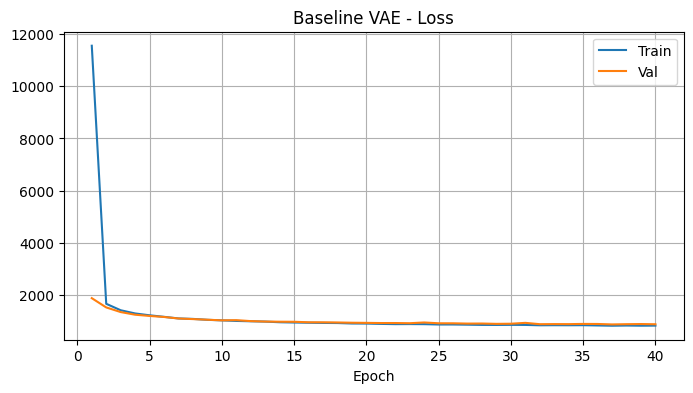

In [24]:
hist_df = pd.DataFrame(baseline_hist)
plt.figure(figsize=(8,4))
plt.plot(hist_df['epoch'], hist_df['train_loss'], label='Train')
plt.plot(hist_df['epoch'], hist_df['val_loss'], label='Val')
plt.title('Baseline VAE - Loss'); plt.xlabel('Epoch'); plt.legend(); plt.grid(True)
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/vae_baseline_loss.png', dpi=150); plt.show()

### 4b. Reconstruções Visuais

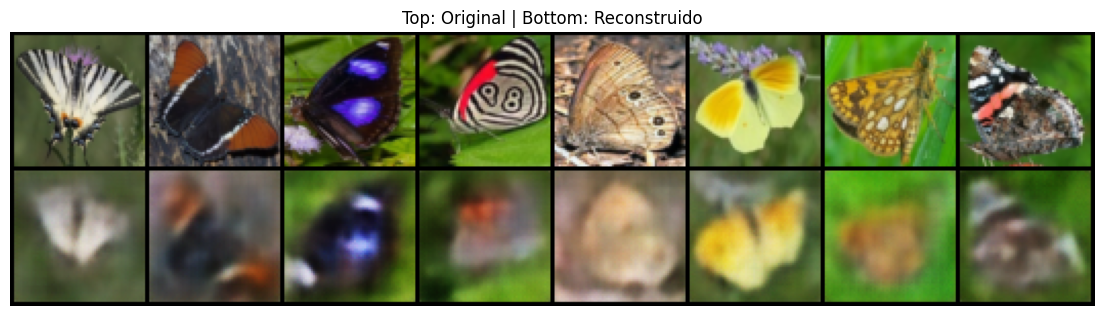

In [25]:
vae_baseline.eval()
sample, _ = next(iter(val_ld))
sample = sample[:8].to(device)
with torch.no_grad():
    recon = vae_baseline.reconstruct(sample)

grid = vutils.make_grid(torch.cat([denorm(sample.cpu()), denorm(recon.cpu())]), nrow=8, padding=2)
plt.figure(figsize=(14, 4))
plt.imshow(grid.permute(1,2,0))
plt.title('Top: Original | Bottom: Reconstruido'); plt.axis('off')
plt.savefig('../outputs/vae_reconstructions.png', dpi=150, bbox_inches='tight'); plt.show()

### 4c. Amostras Geradas

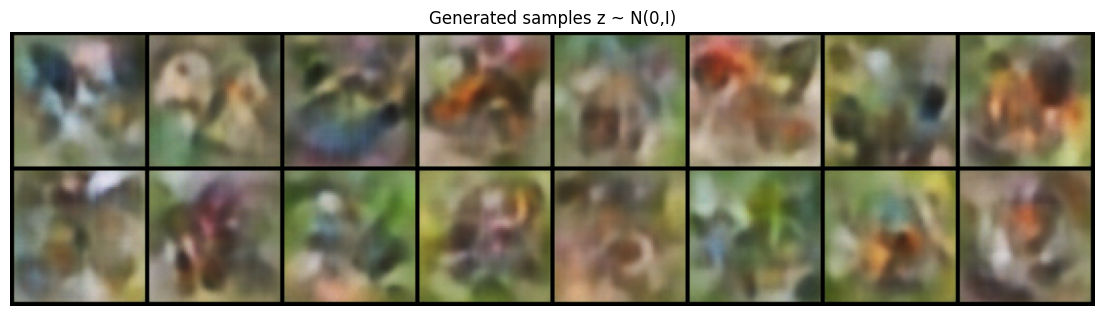

In [26]:
with torch.no_grad():
    gen = vae_baseline.generate(n=16, device=device)
grid = vutils.make_grid(denorm(gen.cpu()), nrow=8, padding=2)
plt.figure(figsize=(14, 4))
plt.imshow(grid.permute(1,2,0))
plt.title('Generated samples z ~ N(0,I)'); plt.axis('off')
plt.savefig('../outputs/vae_generated.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. Métricas de Avaliação do Modelo Generativo

Os professores pedem métricas da literatura para avaliar a qualidade das imagens geradas:
- **SSIM** (Structural Similarity Index) — qualidade das reconstruções
- **FID** (Fréchet Inception Distance) — distância entre distribuições real vs gerada (menor = melhor)
- **IS** (Inception Score) — qualidade e diversidade das imagens geradas (maior = melhor)

In [27]:
import numpy as np
from skimage.metrics import structural_similarity

# ── SSIM sobre as reconstruções do val set ─────────────────────────────────────
vae_baseline.eval()
ssim_scores = []
with torch.no_grad():
    for imgs, _ in val_ld:
        imgs = imgs.to(device)
        recon = vae_baseline.reconstruct(imgs)
        orig_np  = denorm(imgs).cpu().permute(0,2,3,1).numpy()
        recon_np = denorm(recon).cpu().permute(0,2,3,1).numpy()
        for o, r in zip(orig_np, recon_np):
            score = structural_similarity(o, r, data_range=1.0, channel_axis=2)
            ssim_scores.append(score)
mean_ssim = np.mean(ssim_scores)
print(f'SSIM (val reconstructions): {mean_ssim:.4f}  (range [0,1], higher=better)')

SSIM (val reconstructions): 0.4604  (range [0,1], higher=better)


In [28]:
import warnings
warnings.filterwarnings('ignore')
import torchvision.models as tv_models
import torch.nn.functional as F
from scipy import linalg

# ── InceptionV3 para FID e IS (mesmo método que os notebooks GAN) ─────────────
metric_device = torch.device('cpu') if device.type == 'mps' else device
inception = tv_models.inception_v3(weights='DEFAULT', transform_input=False).to(metric_device)
inception.eval()

def get_inception_features(imgs_tensor):
    """Extrai features 2048-d do avgpool do InceptionV3. imgs_tensor em [0,1], (N,3,H,W)."""
    imgs_299 = F.interpolate(imgs_tensor.to(metric_device), size=(299, 299),
                              mode='bilinear', align_corners=False)
    feats = []
    def hook(m, i, o): feats.append(o.squeeze(-1).squeeze(-1))
    h = inception.avgpool.register_forward_hook(hook)
    with torch.no_grad():
        inception(imgs_299)
    h.remove()
    return feats[0].cpu().numpy()

def compute_fid(real_feats, fake_feats):
    """FID entre dois conjuntos de features numpy (N, 2048)."""
    mu1, sigma1 = real_feats.mean(0), np.cov(real_feats, rowvar=False)
    mu2, sigma2 = fake_feats.mean(0), np.cov(fake_feats, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))

def compute_is(imgs_tensor, splits=10):
    """Inception Score a partir de um tensor de imagens [0,1]."""
    imgs_299 = F.interpolate(imgs_tensor.to(metric_device), size=(299, 299),
                              mode='bilinear', align_corners=False)
    logits_list = []
    with torch.no_grad():
        for i in range(0, len(imgs_299), 64):
            logits_list.append(inception(imgs_299[i:i+64]).cpu())
    pyx  = torch.softmax(torch.cat(logits_list), dim=1).numpy()
    py   = pyx.mean(0)
    kl   = pyx * (np.log(pyx + 1e-8) - np.log(py + 1e-8))
    scores = np.exp(kl.sum(1))
    chunks = np.array_split(scores, splits)
    return float(np.mean([c.mean() for c in chunks])), float(np.std([c.mean() for c in chunks]))

print('Funções de avaliação definidas (método idêntico ao dos notebooks GAN).')

# ── Calcular FID e IS para o Baseline VAE ─────────────────────────────────────
N_GEN = 500

# Features das imagens REAIS (val set)
real_imgs_list = []
for imgs, _ in val_ld:
    real_imgs_list.append(denorm(imgs))
real_imgs_all = torch.cat(real_imgs_list, dim=0)  # (N, 3, 64, 64) em [0,1]

print('A extrair features das imagens reais...')
real_feats = []
for i in range(0, len(real_imgs_all), 64):
    real_feats.append(get_inception_features(real_imgs_all[i:i+64]))
real_feats = np.concatenate(real_feats, axis=0)

# Features das imagens GERADAS
vae_baseline.eval()
generated_all = []
with torch.no_grad():
    for start in range(0, N_GEN, BATCH_SIZE):
        n = min(BATCH_SIZE, N_GEN - start)
        z = torch.randn(n, vae_baseline.latent_dim, device=device)
        gen = vae_baseline.decoder(z)
        generated_all.append(denorm(gen).cpu())
generated_all = torch.cat(generated_all, dim=0)

print('A extrair features das imagens geradas...')
fake_feats = []
for i in range(0, len(generated_all), 64):
    fake_feats.append(get_inception_features(generated_all[i:i+64]))
fake_feats = np.concatenate(fake_feats, axis=0)

fid_score = compute_fid(real_feats, fake_feats)
is_mean, is_std = compute_is(generated_all)

print(f'FID  : {fid_score:.2f}  (lower is better)')
print(f'IS   : {is_mean:.2f} +/- {is_std:.2f}  (higher is better)')
print(f'SSIM : {mean_ssim:.4f}  (higher is better)')

baseline_metrics = {'ssim': float(mean_ssim), 'fid': float(fid_score), 'is_mean': float(is_mean), 'is_std': float(is_std)}
with open('../outputs/vae_baseline_metrics.json', 'w') as f:
    json.dump(baseline_metrics, f, indent=2)
print('Baseline VAE metrics saved.')


Funções de avaliação definidas (método idêntico ao dos notebooks GAN).
A extrair features das imagens reais...
A extrair features das imagens geradas...
FID  : 305.00  (lower is better)
IS   : 1.88 +/- 0.40  (higher is better)
SSIM : 0.4604  (higher is better)
Baseline VAE metrics saved.


## 6. Grid Search de Hiperparâmetros

Exploramos sistematicamente combinações de:
- `latent_dim` — tamanho do espaço latente
- `beta` — peso do termo KL (controla o trade-off disentanglement vs reconstrução)
- `lr` — taxa de aprendizagem

Métrica de selecção: **Val Loss** (mais rápido que FID para grid search).

In [10]:
PARAM_GRID = {
    'latent_dim': [64, 128, 256, 512],
    'beta':       [0.5, 1.0, 2.0],
    'lr':         [1e-3, 5e-4, 1e-4],
}

combinations = list(itertools.product(
    PARAM_GRID['latent_dim'],
    PARAM_GRID['beta'],
    PARAM_GRID['lr'],
))
print(f'Total combinations: {len(combinations)}')
print('Grid Search started (usando 15 épocas + patience=3 por combinação)...')

grid_results = []
for latent_dim, beta, lr in combinations:
    print(f'  latent_dim={latent_dim}, beta={beta}, lr={lr} ... ', end='')
    _, val_loss, _, val_recon = train_vae(latent_dim=latent_dim, beta=beta, lr=lr, epochs=15, patience=3)
    grid_results.append({'latent_dim': latent_dim, 'beta': beta, 'lr': lr, 'val_loss': val_loss, 'val_recon': val_recon})
    print(f'val_loss={val_loss:.4f}, val_recon={val_recon:.4f}')

grid_df = pd.DataFrame(grid_results).sort_values('val_recon')
print('\nGrid Search Results:')

Total combinations: 36
Grid Search started (usando 15 épocas + patience=3 por combinação)...
  latent_dim=64, beta=0.5, lr=0.001 ... val_loss=1033.7914, val_recon=954.1100
  latent_dim=64, beta=0.5, lr=0.0005 ... val_loss=892.0939, val_recon=816.9446
  latent_dim=64, beta=0.5, lr=0.0001 ... val_loss=992.3948, val_recon=920.7697
  latent_dim=64, beta=1.0, lr=0.001 ...   [EarlyStopping] Epoch 14/15
val_loss=960.3387, val_recon=841.9104
  latent_dim=64, beta=1.0, lr=0.0005 ... val_loss=952.7585, val_recon=834.8859
  latent_dim=64, beta=1.0, lr=0.0001 ... val_loss=1053.1744, val_recon=939.1464
  latent_dim=64, beta=2.0, lr=0.001 ... val_loss=1108.7275, val_recon=923.3926
  latent_dim=64, beta=2.0, lr=0.0005 ... val_loss=1057.3637, val_recon=895.4306
  latent_dim=64, beta=2.0, lr=0.0001 ... val_loss=1180.6375, val_recon=1013.3663
  latent_dim=128, beta=0.5, lr=0.001 ... val_loss=789.0763, val_recon=680.6090
  latent_dim=128, beta=0.5, lr=0.0005 ... val_loss=792.1421, val_recon=680.0030
  la

In [11]:
from IPython import display
# ── Selecção do melhor config baseada em FID (2048-d, idêntico ao GAN) ────────
FID_SUBSET = 1040

top_k = grid_df.head(6)
print(f'A calcular FID (2048-d, InceptionV3) para os top-{len(top_k)} configs...')

# Calcular features das imagens REAIS uma vez só (reutilizadas para todos os modelos)
real_imgs_for_fid = []
for imgs, _ in val_ld:
    real_imgs_for_fid.append(denorm(imgs))  # [0,1]
    if sum(x.shape[0] for x in real_imgs_for_fid) >= FID_SUBSET:
        break
real_imgs_cat_gs = torch.cat(real_imgs_for_fid, dim=0)[:FID_SUBSET]

print('A extrair features das imagens reais...')
real_feats_gs = []
for i in range(0, len(real_imgs_cat_gs), 64):
    real_feats_gs.append(get_inception_features(real_imgs_cat_gs[i:i+64]))
real_feats_gs = np.concatenate(real_feats_gs, axis=0)

fid_scores = []
for _, row in top_k.iterrows():
    ld, b, lr_ = int(row['latent_dim']), float(row['beta']), float(row['lr'])
    vae_tmp, _, _, _ = train_vae(latent_dim=ld, beta=b, lr=lr_, epochs=20, patience=4)
    vae_tmp.eval()
    with torch.no_grad():
        z = torch.randn(FID_SUBSET, ld, device=device)
        gen = vae_tmp.decoder(z)
        gen_imgs = denorm(gen).cpu()  # [0,1]
    fake_feats_gs = []
    for i in range(0, len(gen_imgs), 64):
        fake_feats_gs.append(get_inception_features(gen_imgs[i:i+64]))
    fake_feats_gs = np.concatenate(fake_feats_gs, axis=0)
    fid_val = compute_fid(real_feats_gs, fake_feats_gs)
    fid_scores.append({'latent_dim': ld, 'beta': b, 'lr': lr_, 'val_loss': row['val_loss'], 'fid': fid_val})
    print(f'  latent_dim={ld}, beta={b}, lr={lr_} → FID={fid_val:.4f}')

fid_grid_df = pd.DataFrame(fid_scores).sort_values('fid')
print('\nTop configs por FID:')
print(fid_grid_df)

best = fid_grid_df.iloc[0]
BEST_LATENT = int(best['latent_dim'])
BEST_BETA   = float(best['beta'])
BEST_LR     = float(best['lr'])
print(f'\nMelhor config (por FID): latent_dim={BEST_LATENT}, beta={BEST_BETA}, lr={BEST_LR}')
print(f'  val_loss={best["val_loss"]:.4f}  |  FID={best["fid"]:.4f}')


A calcular FID (2048-d, InceptionV3) para os top-6 configs...
A extrair features das imagens reais...
  latent_dim=256, beta=0.5, lr=0.0005 → FID=284.8884
  latent_dim=128, beta=0.5, lr=0.0005 → FID=262.4327
  latent_dim=128, beta=0.5, lr=0.001 → FID=274.5995
  latent_dim=256, beta=0.5, lr=0.001 → FID=304.7541
  latent_dim=512, beta=0.5, lr=0.0005 → FID=310.3173
  latent_dim=512, beta=0.5, lr=0.001 → FID=342.4613

Top configs por FID:
   latent_dim  beta      lr    val_loss         fid
1         128   0.5  0.0005  792.142072  262.432682
2         128   0.5  0.0010  789.076287  274.599532
0         256   0.5  0.0005  800.420579  284.888357
3         256   0.5  0.0010  841.756987  304.754066
4         512   0.5  0.0005  858.319691  310.317282
5         512   0.5  0.0010  889.016541  342.461325

Melhor config (por FID): latent_dim=128, beta=0.5, lr=0.0005
  val_loss=792.1421  |  FID=262.4327


## 7. Treino Final com Melhor Configuração

In [12]:
print(f'Training best VAE: latent_dim={BEST_LATENT}, beta={BEST_BETA}, lr={BEST_LR}')

CKPT_DIR = '../outputs/ckpts'
os.makedirs(CKPT_DIR, exist_ok=True)

vae_best, best_val_loss, best_hist, _ = train_vae(
    latent_dim=BEST_LATENT, beta=BEST_BETA, lr=BEST_LR,
    epochs=60, patience=7,
    ckpt_path=f'{CKPT_DIR}/vae_best',  # guarda checkpoint a cada 10 epochs
    save_every=10,
)
print(f'Best VAE final val loss: {best_val_loss:.4f}')

os.makedirs('../outputs/models', exist_ok=True)
torch.save(vae_best.state_dict(), '../outputs/models/vae_best.pth')

# Save best config
with open('../outputs/vae_best_config.json', 'w') as f:
    json.dump({'latent_dim': BEST_LATENT, 'beta': BEST_BETA, 'lr': BEST_LR,
               'val_loss': float(best_val_loss)}, f, indent=2)
print('Best VAE saved.')


Training best VAE: latent_dim=128, beta=0.5, lr=0.0005
  [Checkpoint] A retomar de: ../outputs/ckpts/vae_best_epoch_0040.pt
  [Checkpoint] Epoch 40/60 | best_loss=744.6295
  [EarlyStopping] Epoch 46/60
Best VAE final val loss: 744.6295
Best VAE saved.


### 7a. Métricas do Melhor VAE

In [13]:
from skimage.metrics import structural_similarity
# ── SSIM do Best VAE ──────────────────────────────────────────────────────────
vae_best.eval()
ssim_scores_best = []
with torch.no_grad():
    for imgs, _ in val_ld:
        imgs = imgs.to(device)
        recon = vae_best.reconstruct(imgs)
        orig_np  = denorm(imgs).cpu().permute(0,2,3,1).numpy()
        recon_np = denorm(recon).cpu().permute(0,2,3,1).numpy()
        for o, r in zip(orig_np, recon_np):
            ssim_scores_best.append(structural_similarity(o, r, data_range=1.0, channel_axis=2))
mean_ssim_best = np.mean(ssim_scores_best)

# ── FID e IS do Best VAE (método idêntico ao GAN — InceptionV3 manual, 2048-d) ─
print('A calcular FID e IS do Best VAE (método 2048-d, idêntico ao GAN)...')

# Gerar N_GEN imagens com o Best VAE
vae_best.eval()
generated_best = []
with torch.no_grad():
    for start in range(0, N_GEN, BATCH_SIZE):
        n = min(BATCH_SIZE, N_GEN - start)
        z = torch.randn(n, vae_best.latent_dim, device=device)
        gen = vae_best.decoder(z)
        generated_best.append(denorm(gen).cpu())
generated_best = torch.cat(generated_best, dim=0)

# Features das imagens geradas
fake_feats_best = []
for i in range(0, len(generated_best), 64):
    fake_feats_best.append(get_inception_features(generated_best[i:i+64]))
fake_feats_best = np.concatenate(fake_feats_best, axis=0)

fid_best   = compute_fid(real_feats, fake_feats_best)  # real_feats ja calculado na cell 17
is_best_mean, is_best_std = compute_is(generated_best)

print('='*55)
print('COMPARISON: Baseline VAE vs Best VAE')
print('='*55)
print(f'{"Metric":<12} {"Baseline":>12} {"Best VAE":>12}')
print('-'*55)
print(f'{"SSIM":<12} {baseline_metrics["ssim"]:>12.4f} {mean_ssim_best:>12.4f}  (higher=better)')
print(f'{"FID":<12} {baseline_metrics["fid"]:>12.2f} {fid_best:>12.2f}  (lower=better)')
print(f'{"IS":<12} {baseline_metrics["is_mean"]:>12.2f} {is_best_mean:>12.2f}  (higher=better)')
print('='*55)
print('NOTA: FID calculado com InceptionV3 avgpool (2048-d), F.interpolate 299x299')
print('      Método idêntico ao usado nos notebooks GAN — valores directamente comparáveis.')


A calcular FID e IS do Best VAE (método 2048-d, idêntico ao GAN)...
COMPARISON: Baseline VAE vs Best VAE
Metric           Baseline     Best VAE
-------------------------------------------------------
SSIM               0.4769       0.4825  (higher=better)
FID                255.80       264.41  (lower=better)
IS                   1.97         1.96  (higher=better)
NOTA: FID calculado com InceptionV3 avgpool (2048-d), F.interpolate 299x299
      Método idêntico ao usado nos notebooks GAN — valores directamente comparáveis.


## 8. Gerar Dataset Aumentado

In [14]:
N_PER_CLASS = 75
GEN_DIR = '../outputs/generated_vae'
os.makedirs(GEN_DIR, exist_ok=True)

vae_best.eval()
generated_records = []
to_pil = T.ToPILImage()
plain_tf = T.Compose([T.Resize((IMAGE_SIZE,IMAGE_SIZE)), T.ToTensor(),
                      T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])])

for cls in tqdm(classes, desc='Generating images'):
    cls_dir = os.path.join(GEN_DIR, cls)
    os.makedirs(cls_dir, exist_ok=True)
    cls_rows = train_df[train_df['label'] == cls]
    sample_rows = cls_rows.sample(min(N_PER_CLASS, len(cls_rows)), random_state=SEED)
    imgs_list = [plain_tf(Image.open(os.path.join(train_dir, r['filename'])).convert('RGB'))
                 for _, r in sample_rows.iterrows()]
    imgs_t = torch.stack(imgs_list).to(device)
    with torch.no_grad():
        mu, lv = vae_best.encoder(imgs_t)
        std = lv.mul(0.5).exp()  # std do espaço latente
        # gerar amostras com 3 escalas de perturbação distintas
        # para aumentar a diversidade das imagens sintéticas
        gen_imgs_list = []
        scales = [0.3, 0.6, 1.0]
        imgs_per_scale = N_PER_CLASS // len(scales) + 1
        for scale in scales:
            z = mu + scale * std * torch.randn_like(mu)
            gen_imgs_list.append(vae_best.decoder(z))
        gen_imgs = torch.cat(gen_imgs_list, dim=0)[:N_PER_CLASS]
    for i, img_t in enumerate(denorm(gen_imgs.cpu())):
        fname = f'gen_{cls}_{i:04d}.png'
        to_pil(img_t).save(os.path.join(cls_dir, fname))
        generated_records.append({'filename': os.path.join(cls, fname), 'label': cls})

gen_df = pd.DataFrame(generated_records)
print(f'Generated {len(gen_df)} images across {len(classes)} classes.')


Generating images:   0%|          | 0/75 [00:00<?, ?it/s]

Generated 5625 images across 75 classes.


## 9. Retreinar Baseline CNN com Dados Aumentados

O Baseline CNN e todos os seus hiperparâmetros mantêm-se exactamente iguais — só os dados de treino mudam.

In [15]:
from torch.utils.data import ConcatDataset

train_tf, val_tf = get_transforms()

orig_ds = ButterflyDataset(df=train_df, img_dir=train_dir,  transform=train_tf)
gen_ds  = ButterflyDataset(df=gen_df,   img_dir=GEN_DIR,    transform=train_tf)
val_ds_cls = ButterflyDataset(df=val_df, img_dir=train_dir, transform=val_tf)

aug_loader = data.DataLoader(ConcatDataset([orig_ds, gen_ds]), batch_size=32, shuffle=True, num_workers=0)
val_loader = data.DataLoader(val_ds_cls, batch_size=32, shuffle=False, num_workers=0)

model_aug = BaselineCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_aug.parameters(), lr=1e-3)

EPOCHS, PATIENCE = 150, 15
best_f1, no_imp = 0.0, 0
best_path = '../outputs/models/baseline_cnn_vae_aug.pth'

for epoch in range(EPOCHS):
    model_aug.train()
    for imgs, labels in tqdm(aug_loader, desc=f'Epoch {epoch+1}/{EPOCHS}', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_aug(imgs), labels)
        loss.backward(); optimizer.step()

    model_aug.eval()
    p_all, l_all = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            p_all.extend(model_aug(imgs.to(device)).argmax(1).cpu().numpy())
            l_all.extend(labels.numpy())
    val_f1 = f1_score(l_all, p_all, average='weighted')
    val_acc = accuracy_score(l_all, p_all)
    print(f'Epoch {epoch+1:02d} | Val Acc: {val_acc:.4f}  F1: {val_f1:.4f}')
    if val_f1 > best_f1:
        best_f1 = val_f1; no_imp = 0
        torch.save(model_aug.state_dict(), best_path)
        print(f'   Best saved (F1={best_f1:.4f})')
    else:
        no_imp += 1
        if no_imp >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}'); break

Epoch 1/150:   0%|          | 0/306 [00:00<?, ?it/s]

Epoch 01 | Val Acc: 0.0625  F1: 0.0223
   Best saved (F1=0.0223)


Epoch 2/150:   0%|          | 0/306 [00:00<?, ?it/s]

Epoch 02 | Val Acc: 0.0788  F1: 0.0367
   Best saved (F1=0.0367)


Epoch 3/150:   0%|          | 0/306 [00:00<?, ?it/s]

...

Epoch 90 | Val Acc: 0.7250  F1: 0.7164


Epoch 91/150:   0%|          | 0/306 [00:00<?, ?it/s]

Epoch 91 | Val Acc: 0.7327  F1: 0.7292


Epoch 92/150:   0%|          | 0/306 [00:00<?, ?it/s]

Epoch 92 | Val Acc: 0.7308  F1: 0.7216
Early stopping at epoch 92


## 10. Comparação Final

In [16]:
model_aug.load_state_dict(torch.load(best_path, map_location=device))
model_aug.eval()
p_all, l_all = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        p_all.extend(model_aug(imgs.to(device)).argmax(1).cpu().numpy())
        l_all.extend(labels.numpy())
aug_acc = accuracy_score(l_all, p_all)
aug_f1  = f1_score(l_all, p_all, average='weighted')

with open('../outputs/baseline_results.json') as f:
    base = json.load(f)

print('='*55)
print('BASELINE CNN vs VAE-AUGMENTED CNN (Validation Set)')
print('='*55)
print(f'{"Model":<35} {"Acc":>8} {"F1":>8}')
print('-'*55)
print(f'{"Baseline CNN (original data)":<35} {base["val_accuracy"]:>8.4f} {base["val_f1_weighted"]:>8.4f}')
print(f'{"Baseline CNN + VAE augmentation":<35} {aug_acc:>8.4f} {aug_f1:>8.4f}')
print('='*55)
print(f'Delta Acc: {aug_acc - base["val_accuracy"]:+.4f}  |  Delta F1: {aug_f1 - base["val_f1_weighted"]:+.4f}')

with open('../outputs/vae_aug_results.json', 'w') as f:
    json.dump({'model': 'Baseline CNN + VAE aug', 'val_accuracy': float(aug_acc), 'val_f1_weighted': float(aug_f1),
               'vae_config': {'latent_dim': BEST_LATENT, 'beta': BEST_BETA, 'lr': BEST_LR},
               'generative_metrics': {'ssim': float(mean_ssim_best), 'fid': float(fid_best), 'is_mean': float(is_best_mean)}},
              f, indent=2)
print('Results saved.')

BASELINE CNN vs VAE-AUGMENTED CNN (Validation Set)
Model                                    Acc       F1
-------------------------------------------------------
Baseline CNN (original data)          0.7952   0.7970
Baseline CNN + VAE augmentation       0.7394   0.7377
Delta Acc: -0.0558  |  Delta F1: -0.0593
Results saved.


In [17]:
# ── Submission Kaggle — VAE-Augmented CNN ─────────────────────────────────────
import os
from PIL import Image

# Carregar o modelo treinado com augmentação VAE
model_aug.load_state_dict(torch.load(best_path, map_location=device))
model_aug.eval()

# Dataset de teste (sem labels)
test_dir = os.path.join(os.path.dirname(train_dir), 'test')
test_files = sorted(os.listdir(test_dir))

_, val_tf_sub = get_transforms()

all_filenames = []
all_labels    = []
idx_to_class  = {v: k for k, v in class_to_idx.items()}

with torch.no_grad():
    for fname in test_files:
        img = Image.open(os.path.join(test_dir, fname)).convert('RGB')
        img_t = val_tf_sub(img).unsqueeze(0).to(device)
        pred  = model_aug(img_t).argmax(1).item()
        all_filenames.append(fname)
        all_labels.append(idx_to_class[pred])

submission_df = pd.DataFrame({'filename': all_filenames, 'label': all_labels})
os.makedirs('../outputs/submissions', exist_ok=True)
submission_path = '../outputs/submissions/submission_vae_augmented.csv'
submission_df.to_csv(submission_path, index=False)
print(f' Submissão guardada: {submission_path}')
print(f'   {len(submission_df)} linhas | {submission_df["label"].nunique()} classes distintas')
submission_df.head(5)


 Submissão guardada: ../outputs/submissions/submission_vae_augmented.csv
   1300 linhas | 75 classes distintas


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,CLODIUS PARNASSIAN
2,Image_10.jpg,PIPEVINE SWALLOW
3,Image_100.jpg,RED SPOTTED PURPLE
4,Image_1000.jpg,MALACHITE


## 11. VAE Melhorado (Perceptual Loss + KL Annealing)

Nesta secção, implementamos uma variante melhorada do VAE com o objetivo de gerar imagens mais nítidas e realistas (reduzindo o efeito desfocado gerado pelo MSE pixel-a-pixel).
As melhorias incluem:
1. **Perceptual Loss (VGG-16)**: Utilização de características intermédias da rede VGG-16 pré-treinada para comparar as reconstruções a nível semântico/estrutural, preservando texturas e arestas das asas das borboletas.
2. **KL Annealing**: Um escalonador que começa com $\beta = 0.0$ e aumenta linearmente até ao $\beta$ final ao longo de 15 épocas, permitindo que a rede aprenda primeiro a reconstruir formas e só depois regularize o espaço latente.

In [15]:
import torchvision.models as tv_models
import torch.nn.functional as F

class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        # VGG-16 pré-treinada para extração de features perceptuais
        vgg = tv_models.vgg16(weights='DEFAULT').features.eval()
        for param in vgg.parameters():
            param.requires_grad = False
        
        # Slices correspondentes a: relu1_2 (index 3), relu2_2 (index 8), relu3_3 (index 15)
        self.slices = nn.ModuleList([
            vgg[:4],   # Layer 0 a 3 (relu1_2)
            vgg[4:9],  # Layer 4 a 8 (relu2_2)
            vgg[9:16]  # Layer 9 a 15 (relu3_3)
        ])
        
        # Parâmetros de normalização padrão do ImageNet
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x, y):
        # x e y na gama [0, 1]
        x = (x - self.mean) / self.std
        y = (y - self.mean) / self.std
        
        loss = 0.0
        x_features = x
        y_features = y
        
        for slice_layer in self.slices:
            x_features = slice_layer(x_features)
            y_features = slice_layer(y_features)
            # reduction='mean' divide pelo número de elementos (1/Nj como na fórmula)
            # Multiplicamos pelo número de pixels (12288) para equilibrar com a escala de recon_loss (pixel-level sum)
            loss += F.mse_loss(x_features, y_features, reduction='mean') * (12288 / 3)
            
        return loss

def get_beta(epoch, total_epochs, target_beta, anneal_epochs=15):
    """Retorna beta escalonado linearmente até target_beta nas primeiras anneal_epochs, com um pequeno offset inicial para estabilidade."""
    if epoch < anneal_epochs:
        # Começa em 0.05 * target_beta para dar uma força de restauro inicial estável no MPS
        return target_beta * (0.05 + 0.95 * (epoch / anneal_epochs))
    return target_beta

print("VGGPerceptualLoss e get_beta definidos com sucesso.")

VGGPerceptualLoss e get_beta definidos com sucesso.


In [16]:
def train_vae_improved(latent_dim, target_beta, lr, epochs=60, patience=7, lambda_vgg=0.5, ckpt_path=None, save_every=10):
    vae = VAE(latent_dim=latent_dim).to(device)
    optimizer = optim.Adam(vae.parameters(), lr=lr)
    perceptual_loss_fn = VGGPerceptualLoss().to(device)
    
    best_loss = float('inf')
    no_imp = 0
    
    for epoch in range(epochs):
        vae.train()
        train_loss, train_recon, train_kl, train_vgg = 0.0, 0.0, 0.0, 0.0
        
        # KL annealing
        beta = get_beta(epoch, epochs, target_beta, anneal_epochs=15)
        
        for imgs, _ in tqdm(train_ld, desc=f"Epoch {epoch+1}/{epochs} (beta={beta:.3f})", leave=False):
            imgs = imgs.to(device)
            optimizer.zero_grad()
            
            recon, mu, logvar = vae(imgs)
            
            # Perdas obtidas da vae_loss (mesma escala sum/N do baseline VAE)
            _, recon_loss, kl = vae_loss(recon, imgs, mu, logvar, beta=1.0)
            
            # Perda Perceptual (VGG)
            loss_vgg = perceptual_loss_fn(denorm(recon), denorm(imgs))
            
            # Perda total combinada
            loss_total = recon_loss + lambda_vgg * loss_vgg + beta * kl
            
            loss_total.backward()
            optimizer.step()
            
            train_loss += loss_total.item()
            train_recon += recon_loss.item()
            train_kl += kl.item()
            train_vgg += loss_vgg.item()
            
        # Validação
        vae.eval()
        val_loss, val_recon, val_kl, val_vgg = 0.0, 0.0, 0.0, 0.0
        with torch.no_grad():
            for imgs, _ in val_ld:
                imgs = imgs.to(device)
                recon, mu, logvar = vae(imgs)
                _, recon_loss, kl = vae_loss(recon, imgs, mu, logvar, beta=1.0)
                loss_vgg = perceptual_loss_fn(denorm(recon), denorm(imgs))
                loss_total = recon_loss + lambda_vgg * loss_vgg + beta * kl
                
                val_loss += loss_total.item()
                val_recon += recon_loss.item()
                val_kl += kl.item()
                val_vgg += loss_vgg.item()
                
        n_train, n_val = len(train_ld), len(val_ld)
        train_loss /= n_train; train_recon /= n_train; train_kl /= n_train; train_vgg /= n_train
        val_loss /= n_val; val_recon /= n_val; val_kl /= n_val; val_vgg /= n_val
        
        print(f"Epoch {epoch+1:02d} | Val Loss: {val_loss:.4f} (Recon: {val_recon:.4f}, VGG: {val_vgg:.4f}, KL: {val_kl:.4f})")
        
        if ckpt_path and (epoch + 1) % save_every == 0:
            torch.save(vae.state_dict(), f"{ckpt_path}_epoch_{epoch+1}.pth")
            
        if val_loss < best_loss:
            best_loss = val_loss
            no_imp = 0
            torch.save(vae.state_dict(), ckpt_path if ckpt_path else '../outputs/models/vae_improved.pth')
            print(f"   Melhor VAE melhorado guardado!")
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f"Early stopping at epoch {epoch+1}"); break
                
    # Carrega a melhor versão para retornar
    vae.load_state_dict(torch.load(ckpt_path if ckpt_path else '../outputs/models/vae_improved.pth', map_location=device))
    return vae
print("Função de treino train_vae_improved definida.")


Função de treino train_vae_improved definida.


In [17]:
# ── Treinar o VAE Melhorado ───────────────────────────────────────────────────
# Usamos a melhor configuração encontrada na grid search: latent_dim=128, beta=0.5, lr=0.0005
# lambda_vgg=0.5 equilibra a perda perceptual com o MSE clássico.
vae_improved = train_vae_improved(
    latent_dim=128, 
    target_beta=0.5, 
    lr=0.0005, 
    epochs=60, 
    patience=7, 
    lambda_vgg=0.5,
    ckpt_path='../outputs/models/vae_improved.pth',
    save_every=10
)

Epoch 1/60 (beta=0.025):   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 01 | Val Loss: 89444.5680 (Recon: 3784.4494, VGG: 170995.3566, KL: 6497.6116)
   Melhor VAE melhorado guardado!


Epoch 2/60 (beta=0.057):   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 02 | Val Loss: 85394.0873 (Recon: 3689.7954, VGG: 163366.7463, KL: 369.1550)
   Melhor VAE melhorado guardado!


Epoch 3/60 (beta=0.088):   0%|          | 0/65 [00:00<?, ?it/s]

...

Epoch 53 | Val Loss: 67723.3568 (Recon: 1022.3921, VGG: 132777.2785, KL: 624.6519)


Epoch 54/60 (beta=0.500):   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 54 | Val Loss: 67794.8812 (Recon: 1025.7665, VGG: 132900.4798, KL: 637.7502)


Epoch 55/60 (beta=0.500):   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 55 | Val Loss: 67678.6951 (Recon: 1025.1136, VGG: 132673.1526, KL: 634.0112)
Early stopping at epoch 55


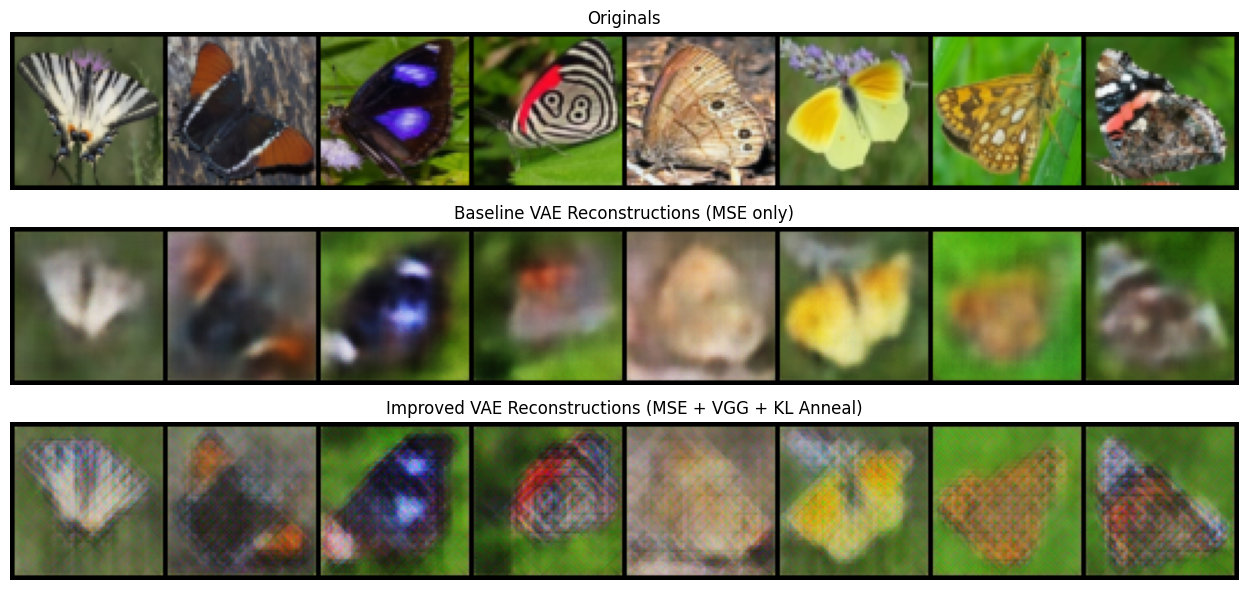

In [20]:
# ── Visualizar Reconstruções Comparativas ──────────────────────────────────────
vae_improved.eval()
vae_baseline.eval()

# Pegar num pequeno batch de teste
imgs_val, _ = next(iter(val_ld))
imgs_val = imgs_val[:8].to(device)

with torch.no_grad():
    recon_base = vae_baseline.reconstruct(imgs_val)
    recon_impr = vae_improved.reconstruct(imgs_val)

orig_grid   = vutils.make_grid(denorm(imgs_val), nrow=8).cpu().permute(1, 2, 0).numpy()
base_grid   = vutils.make_grid(denorm(recon_base), nrow=8).cpu().permute(1, 2, 0).numpy()
impr_grid   = vutils.make_grid(denorm(recon_impr), nrow=8).cpu().permute(1, 2, 0).numpy()

fig, axes = plt.subplots(3, 1, figsize=(15, 6))
axes[0].imshow(orig_grid); axes[0].set_title("Originals"); axes[0].axis('off')
axes[1].imshow(base_grid); axes[1].set_title("Baseline VAE Reconstructions (MSE only)"); axes[1].axis('off')
axes[2].imshow(impr_grid); axes[2].set_title("Improved VAE Reconstructions (MSE + VGG + KL Anneal)"); axes[2].axis('off')
plt.tight_layout()
plt.show()

In [29]:
from skimage.metrics import structural_similarity
# ── Avaliar FID, IS e SSIM do VAE Melhorado ───────────────────────────────────
print('A calcular FID e IS do VAE Melhorado...')
N_GEN=500
# SSIM das reconstruções
ssim_scores_impr = []
with torch.no_grad():
    for imgs, _ in val_ld:
        imgs = imgs.to(device)
        recon = vae_improved.reconstruct(imgs)
        orig_np  = denorm(imgs).cpu().permute(0,2,3,1).numpy()
        recon_np = denorm(recon).cpu().permute(0,2,3,1).numpy()
        for o, r in zip(orig_np, recon_np):
            ssim_scores_impr.append(structural_similarity(o, r, data_range=1.0, channel_axis=2))
mean_ssim_impr = np.mean(ssim_scores_impr)

# Gerar imagens para FID/IS
generated_impr = []
with torch.no_grad():
    for start in range(0, N_GEN, BATCH_SIZE):
        n = min(BATCH_SIZE, N_GEN - start)
        z = torch.randn(n, vae_improved.latent_dim, device=device)
        gen = vae_improved.decoder(z)
        generated_impr.append(denorm(gen).cpu())
generated_impr = torch.cat(generated_impr, dim=0)

# Extrair features
fake_feats_impr = []
for i in range(0, len(generated_impr), 64):
    fake_feats_impr.append(get_inception_features(generated_impr[i:i+64]))
fake_feats_impr = np.concatenate(fake_feats_impr, axis=0)

fid_improved = compute_fid(real_feats, fake_feats_impr)
is_impr_mean, is_impr_std = compute_is(generated_impr)

print('='*55)
print('COMPARISON: Baseline VAE vs Improved VAE')
print('='*55)
print(f'{"Metric":<12} {"Baseline VAE":>12} {"Improved VAE":>12}')
print('-'*55)
print(f'{"SSIM":<12} {baseline_metrics["ssim"]:>12.4f} {mean_ssim_impr:>12.4f}')
print(f'{"FID":<12} {baseline_metrics["fid"]:>12.2f} {fid_improved:>12.2f}')
print(f'{"IS":<12} {baseline_metrics["is_mean"]:>12.2f} {is_impr_mean:>12.2f}')
print('='*55)

vae_improved_metrics = {
    'ssim': float(mean_ssim_impr),
    'fid': float(fid_improved),
    'is_mean': float(is_impr_mean),
    'is_std': float(is_impr_std)
}

A calcular FID e IS do VAE Melhorado...
COMPARISON: Baseline VAE vs Improved VAE
Metric       Baseline VAE Improved VAE
-------------------------------------------------------
SSIM               0.4604       0.3057
FID                305.00       370.62
IS                   1.88         1.55


In [30]:
# ── Gerar Dataset Aumentado com VAE Melhorado ─────────────────────────────────
N_PER_CLASS = 75
GEN_DIR_IMPR = '../outputs/generated_vae_improved'
os.makedirs(GEN_DIR_IMPR, exist_ok=True)

vae_improved.eval()
generated_records_impr = []
to_pil = T.ToPILImage()
plain_tf = T.Compose([T.Resize((IMAGE_SIZE,IMAGE_SIZE)), T.ToTensor(),
                      T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])])

for cls in tqdm(classes, desc='Generating images (Improved VAE)'):
    cls_dir = os.path.join(GEN_DIR_IMPR, cls)
    os.makedirs(cls_dir, exist_ok=True)
    cls_rows = train_df[train_df['label'] == cls]
    sample_rows = cls_rows.sample(min(N_PER_CLASS, len(cls_rows)), random_state=SEED)
    imgs_list = [plain_tf(Image.open(os.path.join(train_dir, r['filename'])).convert('RGB'))
                 for _, r in sample_rows.iterrows()]
    imgs_t = torch.stack(imgs_list).to(device)
    with torch.no_grad():
        mu, lv = vae_improved.encoder(imgs_t)
        std = lv.mul(0.5).exp()  # std do espaço latente
        gen_imgs_list = []
        scales = [0.3, 0.6, 1.0]
        for scale in scales:
            z = mu + scale * std * torch.randn_like(mu)
            gen_imgs_list.append(vae_improved.decoder(z))
        gen_imgs = torch.cat(gen_imgs_list, dim=0)[:N_PER_CLASS]
    for i, img_t in enumerate(denorm(gen_imgs.cpu())):
        fname = f'gen_{cls}_{i:04d}.png'
        to_pil(img_t).save(os.path.join(cls_dir, fname))
        generated_records_impr.append({'filename': os.path.join(cls, fname), 'label': cls})

gen_df_impr = pd.DataFrame(generated_records_impr)
print(f'Generated {len(gen_df_impr)} images using VAE-Improved across {len(classes)} classes.')

Generating images (Improved VAE):   0%|          | 0/75 [00:00<?, ?it/s]

Generated 5625 images using VAE-Improved across 75 classes.


In [32]:
# ── Retreinar Baseline CNN com Dados Aumentados (VAE Melhorado) ───────────────

from torch.utils.data import ConcatDataset
from transforms import get_transforms

# Definir as transformações de treino/validação do classificador
train_tf, val_tf = get_transforms()

# Definir fallbacks para as variáveis de treino
if 'EPOCHS' not in globals(): EPOCHS = 150
if 'PATIENCE' not in globals(): PATIENCE = 15


orig_ds = ButterflyDataset(df=train_df, img_dir=train_dir,  transform=train_tf)
gen_ds_impr  = ButterflyDataset(df=gen_df_impr, img_dir=GEN_DIR_IMPR, transform=train_tf)
val_ds_cls = ButterflyDataset(df=val_df, img_dir=train_dir, transform=val_tf)

aug_loader_impr = data.DataLoader(ConcatDataset([orig_ds, gen_ds_impr]), batch_size=32, shuffle=True, num_workers=0)
val_loader = data.DataLoader(val_ds_cls, batch_size=32, shuffle=False, num_workers=0)

model_aug_impr = BaselineCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_aug_impr.parameters(), lr=1e-3)

best_f1_impr, no_imp = 0.0, 0
best_path_impr = '../outputs/models/baseline_cnn_vae_improved_aug.pth'

for epoch in range(EPOCHS):
    model_aug_impr.train()
    for imgs, labels in tqdm(aug_loader_impr, desc=f'Epoch {epoch+1}/{EPOCHS}', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_aug_impr(imgs), labels)
        loss.backward(); optimizer.step()

    model_aug_impr.eval()
    p_all, l_all = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            p_all.extend(model_aug_impr(imgs.to(device)).argmax(1).cpu().numpy())
            l_all.extend(labels.numpy())
    val_f1_impr = f1_score(l_all, p_all, average='weighted')
    val_acc_impr = accuracy_score(l_all, p_all)
    print(f'Epoch {epoch+1:02d} | Val Acc: {val_acc_impr:.4f}  F1: {val_f1_impr:.4f}')
    if val_f1_impr > best_f1_impr:
        best_f1_impr = val_f1_impr; no_imp = 0
        torch.save(model_aug_impr.state_dict(), best_path_impr)
        print(f'   Best saved (F1={best_f1_impr:.4f})')
    else:
        no_imp += 1
        if no_imp >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}'); break

Epoch 1/150:   0%|          | 0/306 [00:00<?, ?it/s]

Epoch 01 | Val Acc: 0.0577  F1: 0.0194
   Best saved (F1=0.0194)


Epoch 2/150:   0%|          | 0/306 [00:00<?, ?it/s]

Epoch 02 | Val Acc: 0.0971  F1: 0.0496
   Best saved (F1=0.0496)


Epoch 3/150:   0%|          | 0/306 [00:00<?, ?it/s]

...

Epoch 123 | Val Acc: 0.8029  F1: 0.8027


Epoch 124/150:   0%|          | 0/306 [00:00<?, ?it/s]

Epoch 124 | Val Acc: 0.8010  F1: 0.8030


Epoch 125/150:   0%|          | 0/306 [00:00<?, ?it/s]

Epoch 125 | Val Acc: 0.8048  F1: 0.8065
Early stopping at epoch 125


In [34]:
# ── Comparação de Resultados Finais ───────────────────────────────────────────
model_aug_impr.load_state_dict(torch.load(best_path_impr, map_location=device))
model_aug_impr.eval()

# Avaliar melhor modelo
p_all, l_all = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        p_all.extend(model_aug_impr(imgs.to(device)).argmax(1).cpu().numpy())
        l_all.extend(labels.numpy())
final_f1_impr = f1_score(l_all, p_all, average='weighted')
final_acc_impr = accuracy_score(l_all, p_all)

# Ler resultados do baseline CNN e do baseline VAE aug
with open('../outputs/baseline_results.json', 'r') as f:
    base_res = json.load(f)
with open('../outputs/vae_aug_results.json', 'r') as f:
    vae_base_res = json.load(f)

print('='*70)
print('COMPARISON: Baseline CNN vs VAE vs VAE-Improved')
print('='*70)
print(f'{"Model":<35} {"Val Acc":>12} {"Val F1":>12}')
print('-'*70)
print(f'{"Baseline CNN (Original Data)":<35} {base_res.get("val_accuracy", 0.0):>12.4f} {base_res.get("val_f1_weighted", 0.0):>12.4f}')
print(f'{"Baseline CNN + VAE Aug":<35} {vae_base_res.get("val_accuracy", 0.0):>12.4f} {vae_base_res.get("val_f1_weighted", 0.0):>12.4f}')
print(f'{"Baseline CNN + VAE-Improved Aug":<35} {final_acc_impr:>12.4f} {final_f1_impr:>12.4f}')
print('='*70)

# Guardar os resultados do VAE Melhorado
vae_improved_results = {
    'model': 'Baseline CNN + VAE-Improved aug',
    'val_accuracy': float(final_acc_impr),
    'val_f1_weighted': float(final_f1_impr),
    'vae_config': {'latent_dim': 128, 'beta': 0.5, 'lr': 0.0005},
    'generative_metrics': vae_improved_metrics
}
with open('../outputs/vae_improved_aug_results.json', 'w') as f:
    json.dump(vae_improved_results, f, indent=2)

COMPARISON: Baseline CNN vs VAE vs VAE-Improved
Model                                    Val Acc       Val F1
----------------------------------------------------------------------
Baseline CNN (Original Data)              0.7952       0.7970
Baseline CNN + VAE Aug                    0.7394       0.7377
Baseline CNN + VAE-Improved Aug           0.8221       0.8201


In [36]:
# ── Submissão Kaggle — VAE-Improved Augmented CNN ─────────────────────────────
import os
from transforms import get_transforms

# Definir a pasta de teste e os seus ficheiros
test_dir = os.path.join(os.path.dirname(train_dir), 'test')
test_files = sorted(os.listdir(test_dir))

# Carregar a transformação correta para as imagens de teste
_, val_tf_sub = get_transforms()

all_filenames = []
all_labels    = []
idx_to_class  = {v: k for k, v in class_to_idx.items()}

with torch.no_grad():
    for fname in test_files:
        img = Image.open(os.path.join(test_dir, fname)).convert('RGB')
        img_t = val_tf_sub(img).unsqueeze(0).to(device)
        pred  = model_aug_impr(img_t).argmax(1).item()
        all_filenames.append(fname)
        all_labels.append(idx_to_class[pred])

submission_df_impr = pd.DataFrame({'filename': all_filenames, 'label': all_labels})
submission_path_impr = '../outputs/submissions/submission_vae_improved_augmented.csv'
submission_df_impr.to_csv(submission_path_impr, index=False)
print(f' Submissão do VAE Melhorado guardada: {submission_path_impr}')
print(f'   {len(submission_df_impr)} linhas | {submission_df_impr["label"].nunique()} classes distintas')
submission_df_impr.head(5)

 Submissão do VAE Melhorado guardada: ../outputs/submissions/submission_vae_improved_augmented.csv
   1300 linhas | 75 classes distintas


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,CLODIUS PARNASSIAN
2,Image_10.jpg,PIPEVINE SWALLOW
3,Image_100.jpg,RED SPOTTED PURPLE
4,Image_1000.jpg,MALACHITE
